# Telco Customer Churn
- Бизнес‑смысл: заранее понять, какие клиенты с высокой вероятностью уйдут, чтобы предложить удерживающие акции
- ML‑формализация: бинарная классификация: по признакам клиента предсказать Churn = {0,1}
- Метрики:
    1. recall — если важно не пропустить уходящих,
    2. precision — если дорого ошибочно “спасать” тех, кто и так не уйдёт.
    3. я считаю что цена FP и FN сопоставимы => буду использовать f1

In [ ]:
!pip -q install imbalanced-learn

# Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")

In [ ]:
!wget -q -O telco_churn.csv "https://raw.githubusercontent.com/SaeidRostami/Customer_Churn/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

import pandas as pd
df = pd.read_csv("telco_churn.csv")

df.shape, df.head()

((7043, 21),
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
 0  7590-VHVEG  Female              0     Yes         No       1           No   
 1  5575-GNVDE    Male              0      No         No      34          Yes   
 2  3668-QPYBK    Male              0      No         No       2          Yes   
 3  7795-CFOCW    Male              0      No         No      45           No   
 4  9237-HQITU  Female              0      No         No       2          Yes   
 
       MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
 0  No phone service             DSL             No  ...               No   
 1                No             DSL            Yes  ...              Yes   
 2                No             DSL            Yes  ...               No   
 3  No phone service             DSL            Yes  ...              Yes   
 4                No     Fiber optic             No  ...               No   
 
   TechSupport StreamingTV Streamin

# EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##  Приведение типов

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].astype(str).str.strip(), errors="coerce")
df["Churn"] = (df["Churn"].str.strip() == "Yes").astype(int)
df[["tenure","MonthlyCharges","TotalCharges","Churn"]].head()

,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,0
1,34,56.95,1889.50,0
2,2,53.85,108.15,1
3,45,42.30,1840.75,0
4,2,70.70,151.65,1


## Пропуски и базовые статистики

In [ ]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]

,0
TotalCharges,0.001562


In [ ]:
df.describe(include="all").T.head(10)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Дисбаланс классов

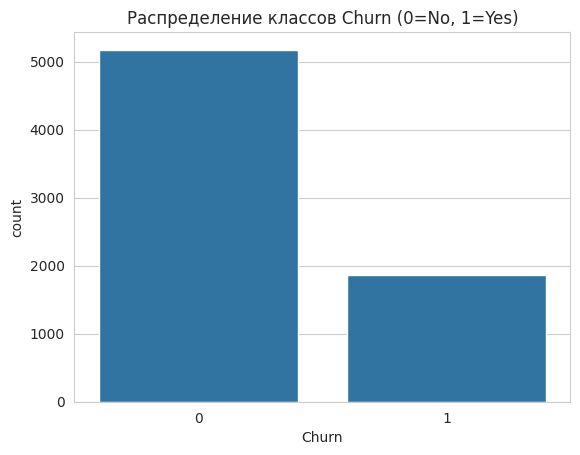

np.float64(0.2653698707936959)

In [ ]:
ax = sns.countplot(x="Churn", data=df)
ax.set_title("Распределение классов Churn (0=No, 1=Yes)")
plt.show()

churn_rate = df["Churn"].mean()
churn_rate

 доля Churn=1 заметно меньше, значит accuracy может врать, и стоит смотреть F1 / ROC‑AUC / PR‑AUC или балансировать классы

## Распределения числовых признаков + корреляции

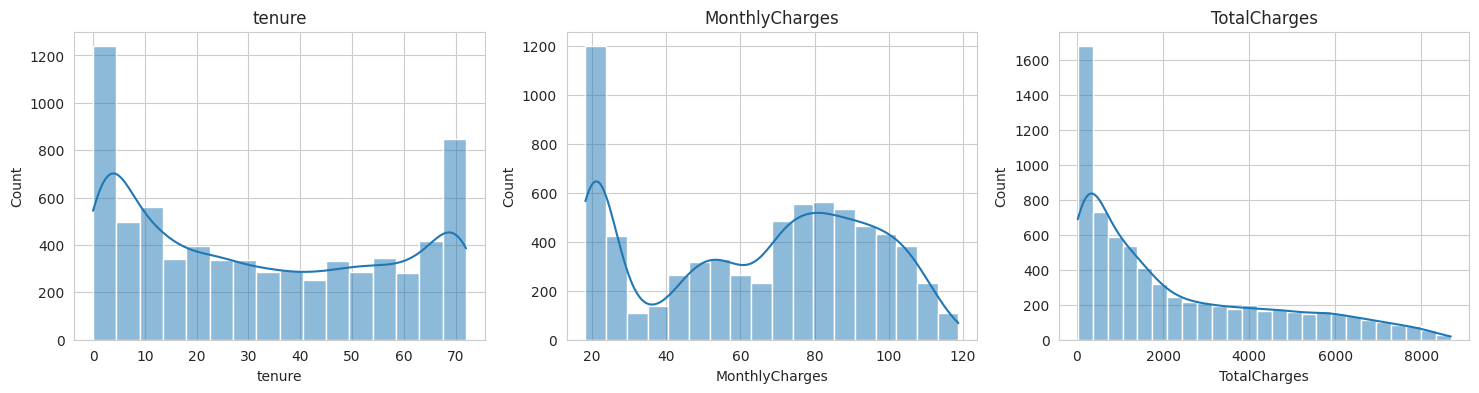

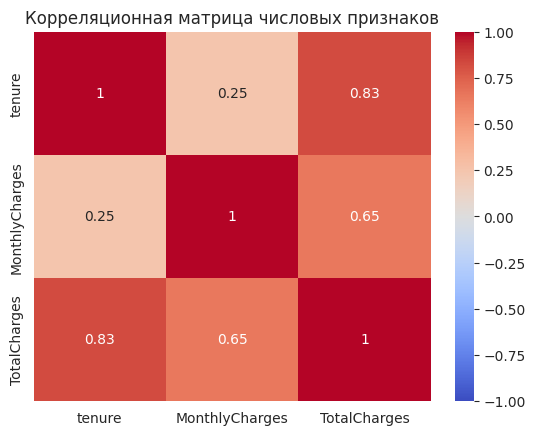

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c], kde=True, ax=ax)
    ax.set_title(c)
plt.show()

corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

corr

обычно `TotalCharges` сильно связан с `tenure`

## Категориальные признаки

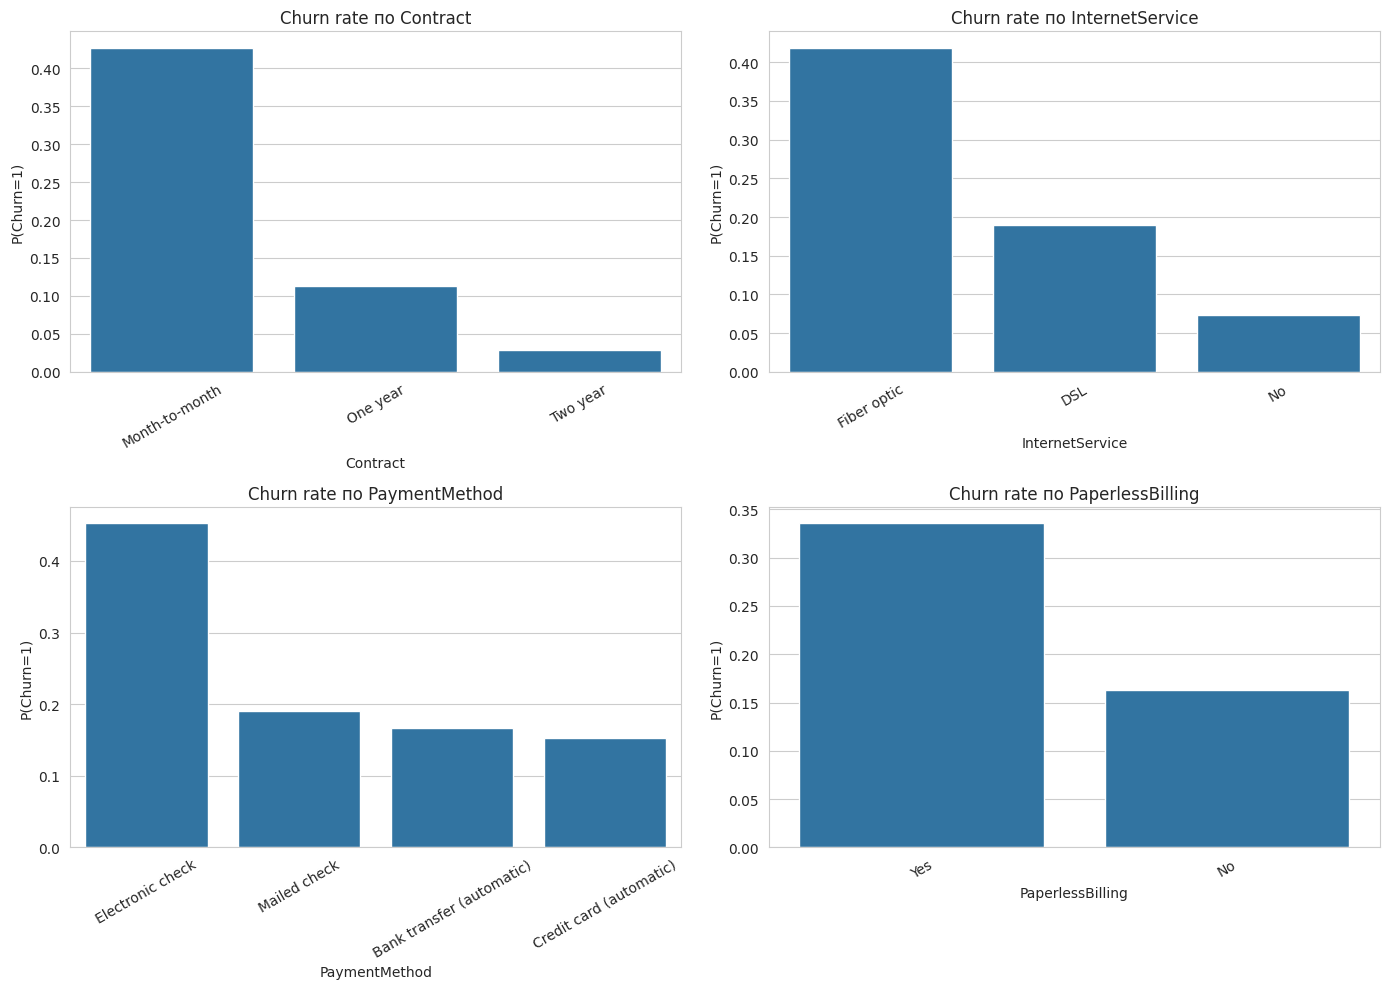

In [ ]:
cat_to_plot = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, c in zip(axes, cat_to_plot):
    tmp = df.groupby(c)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=tmp.index, y=tmp.values, ax=ax)
    ax.set_title(f"Churn rate по {c}")
    ax.set_ylabel("P(Churn=1)")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Train/Test split

In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in X.columns if c not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((5634, 19), (1409, 19))

# KNN - baseline

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)
knn_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier())
])

param_grid = {
    "model__n_neighbors": [3,5,7,9,11,15,21,31,41],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs_knn = GridSearchCV(
    knn_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gs_knn.fit(X_train, y_train)
gs_knn.best_params_, gs_knn.best_score_

Fitting 5 folds for each of 36 candidates, totalling 180 fits


({'model__n_neighbors': 31, 'model__p': 1, 'model__weights': 'uniform'},
 np.float64(0.6069103015476026))

# Оценка качества KNN

In [ ]:
def evaluate(model, Xtr, ytr, Xte, yte, name="model"):
    ytr_pred = model.predict(Xtr)
    yte_pred = model.predict(Xte)

    ytr_score = None
    yte_score = None
    if hasattr(model, "predict_proba"):
        ytr_score = model.predict_proba(Xtr)[:, 1]
        yte_score = model.predict_proba(Xte)[:, 1]
    elif hasattr(model, "decision_function"):
        ytr_score = model.decision_function(Xtr)
        yte_score = model.decision_function(Xte)

    out = {}
    out["name"] = name

    out["train_f1"] = f1_score(ytr, ytr_pred)
    out["test_f1"]  = f1_score(yte, yte_pred)

    if yte_score is not None:
        out["test_roc_auc"] = roc_auc_score(yte, yte_score)
        out["test_pr_auc"]  = average_precision_score(yte, yte_score)
    else:
        out["test_roc_auc"] = np.nan
        out["test_pr_auc"]  = np.nan

    return out

best_knn = gs_knn.best_estimator_
knn_res = evaluate(best_knn, X_train, y_train, X_test, y_test, name="KNN(best)")
knn_res

{'name': 'KNN(best)',
 'train_f1': 0.6313253012048192,
 'test_f1': 0.5877551020408164,
 'test_roc_auc': np.float64(0.8280128652251414),
 'test_pr_auc': np.float64(0.6073040521485459)}

In [ ]:
y_test_pred = best_knn.predict(X_test)
print(classification_report(y_test, y_test_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

           0      0.849     0.860     0.855      1035
           1      0.598     0.578     0.588       374

    accuracy                          0.785      1409
   macro avg      0.724     0.719     0.721      1409
weighted avg      0.783     0.785     0.784      1409

Confusion matrix:
 [[890 145]
 [158 216]]


# LogisticRegression / RF / LightGBM

In [ ]:
models_and_grids = []

logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
])
grid_logreg = {
    "model__C": [0.1, 0.3, 1.0, 3.0, 10.0],
    "model__solver": ["liblinear"]
}
models_and_grids.append(("LogReg(balanced)", logreg, grid_logreg))

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"
    ))
])
grid_rf = {
    "model__max_depth": [None, 6, 10, 14],
    "model__min_samples_leaf": [1, 3, 10],
    "model__max_features": ["sqrt", 0.5]
}
models_and_grids.append(("RF(balanced)", rf, grid_rf))

results = []
best_estimators = {}

for name, pipe, grid in models_and_grids:
    gs = GridSearchCV(pipe, grid, scoring="f1", cv=cv, n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    res = evaluate(gs.best_estimator_, X_train, y_train, X_test, y_test, name=name)
    res["best_params"] = gs.best_params_
    results.append(res)

pd.DataFrame(results).sort_values(by="test_f1", ascending=False)

,name,train_f1,test_f1,test_roc_auc,test_pr_auc,best_params
1,RF(balanced),0.691883,0.63388,0.844017,0.651524,"{'model__max_depth': None, 'model__max_feature..."
0,LogReg(balanced),0.631828,0.61490,0.841096,0.628927,"{'model__C': 3.0, 'model__solver': 'liblinear'}"


# Борьба с несбалансированностью классов(SMOTE)

In [ ]:
smote_logreg = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

grid_smote_logreg = {
    "model__C": [0.1, 0.3, 1.0, 3.0, 10.0],
    "model__solver": ["liblinear"]
}

gs_smote = GridSearchCV(smote_logreg, grid_smote_logreg, scoring="f1", cv=cv, n_jobs=-1)
gs_smote.fit(X_train, y_train)

smote_res = evaluate(gs_smote.best_estimator_, X_train, y_train, X_test, y_test, name="LogReg+SMOTE")
smote_res, gs_smote.best_params_

({'name': 'LogReg+SMOTE',
  'train_f1': 0.6369393139841689,
  'test_f1': 0.6142557651991615,
  'test_roc_auc': np.float64(0.8393655222299723),
  'test_pr_auc': np.float64(0.6283578727045073)},
 {'model__C': 0.1, 'model__solver': 'liblinear'})

In [ ]:
pd.DataFrame([knn_res] + results + [smote_res]).sort_values("test_f1", ascending=False)

,name,train_f1,test_f1,test_roc_auc,test_pr_auc,best_params
2,RF(balanced),0.691883,0.633880,0.844017,0.651524,"{'model__max_depth': None, 'model__max_feature..."
1,LogReg(balanced),0.631828,0.614900,0.841096,0.628927,"{'model__C': 3.0, 'model__solver': 'liblinear'}"
3,LogReg+SMOTE,0.636939,0.614256,0.839366,0.628358,NaN
0,KNN(best),0.631325,0.587755,0.828013,0.607304,NaN


Вывод: как  модель по умолчанию (без дополнительной настройки порога) у меня лучше всего сработал RandomForest с балансировкой.(F1 на тесте RF(balanced) = 0.634)

# Коррелированные переменные

In [ ]:
df[["tenure","MonthlyCharges","TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


In [ ]:
numeric_A = ["tenure", "MonthlyCharges", "TotalCharges"]
numeric_B = ["tenure", "MonthlyCharges"]

def make_preprocess(numeric_features_local):
    categorical_features_local = [c for c in X.columns if c not in numeric_features_local]
    num_tr = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                             ("scaler", StandardScaler())])
    cat_tr = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                             ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer(
        transformers=[
            ("num", num_tr, numeric_features_local),
            ("cat", cat_tr, categorical_features_local),
        ]
    )

pre_A = make_preprocess(numeric_A)
pre_B = make_preprocess(numeric_B)

logreg_A = Pipeline(steps=[("preprocess", pre_A),
                          ("model", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear"))])

logreg_B = Pipeline(steps=[("preprocess", pre_B),
                          ("model", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear"))])

logreg_A.fit(X_train, y_train)
logreg_B.fit(X_train, y_train)

res_A = evaluate(logreg_A, X_train, y_train, X_test, y_test, name="LogReg(all num)")
res_B = evaluate(logreg_B, X_train, y_train, X_test, y_test, name="LogReg(drop TotalCharges)")

pd.DataFrame([res_A, res_B]).sort_values("test_f1", ascending=False)

,name,train_f1,test_f1,test_roc_auc,test_pr_auc
1,LogReg(drop TotalCharges),0.757960,0.621592,0.839329,0.634182
0,LogReg(all num),0.633517,0.613613,0.841474,0.632508


# Вывод
1. Сравнение моделей:
- Лучший результат по качеству предсказания churn (на тесте) показал RandomForest с class_weight="balanced": test_f1 = 0.634, при высоких ROC‑AUC = 0.844 и PR‑AUC = 0.652
- LogisticRegression (balanced) дала немного хуже: test_f1 ≈ 0.615.
- SMOTE для логрегрессии заметного улучшения не дал.
- KNN оказался слабее остальных (ожидаемо для one‑hot табличных данных).
2. Работа с коррелированными признаками: исключение TotalCharges (коррелированного с tenure) улучшило качество логрегрессии на тесте (test_f1 вырос примерно с 0.614 до 0.622), что подтверждает пользу удаления избыточных/производных признаков.

3. Итог: модель RandomForest(balanced) выбрана как лучшая по совокупности метрик на тестовой выборке; линейные модели остались сильными и интерпретируемыми baseline‑решениями. В условиях дисбаланса корректнее ориентироваться на F1/PR‑AUC